In [1]:
#!pip install --upgrade google-cloud-bigquery
#!pip install adjustText

In [2]:
#!pip install db-dtypes pandas-gbq
#!pip install db-dtypes
#!pip install google-cloud-bigquery-storage pyarrow
#!pip install seaborn

from google.cloud import bigquery
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np
try:
    from adjust_text import adjust_text
except ImportError:
    from adjustText import adjust_text # Try the capitalized version
client = bigquery.Client(project= 'moonlit-parsec-485600-p0')

# This query stacks the tables from different dates and unnest the stacked tables
sql = """
SELECT 
    fullVisitorId,
    date,
    p.v2ProductName, 
    p.v2ProductCategory,
    (p.productPrice/1000000) AS unit_price -- Coverts micros to Dollars
FROM
    `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS h,
    UNNEST(h.product) AS p
WHERE
    _TABLE_SUFFIX BETWEEN '20170101' AND '20170630'
    AND h.transaction.transactionId is NOT NULL
"""

df = client.query(sql).to_dataframe()
print(f"Successfully pulled {len(df):,} rows!")
df.head()
df.info()


C:\Users\caitc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Successfully pulled 32,629 rows!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32629 entries, 0 to 32628
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fullVisitorId      32629 non-null  object 
 1   date               32629 non-null  object 
 2   v2ProductName      32629 non-null  object 
 3   v2ProductCategory  32629 non-null  object 
 4   unit_price         32629 non-null  float64
dtypes: float64(1), object(4)
memory usage: 1.2+ MB


In [3]:
df = df.rename(columns = {
    'fullVisitorId' : 'user_id',
    'v2ProductName': 'product_name',
    'v2ProductCategory': 'product_category',
    'unit_price': 'unit_price'
})

#df.info()

agg_df = df.groupby(['user_id','product_name']).size().reset_index(name = 'interaction_count')
agg_df

agg_df.sort_values(by='interaction_count', ascending=False).head(5)

,user_id,product_name,interaction_count
11981,8637158932301658318,Gift Card - $25.00,30
6622,4863941202505455588,Google Sunglasses,20
3406,2402527199731150932,Recycled Paper Journal Set,20
826,0608915197735218105,Google Men's Zip Hoodie,20
2332,1708063999877429517,Google Sunglasses,20


Average items per user: 3.01
Max items by a single user: 68
user_id
1957458976293878100    68
4835082938415020542    46
7311242886083854158    40
9029794295932939024    39
4983264713224875783    38
154104806751769000     38
2396848817613598114    37
7813149961404844386    37
9089132392240687728    36
6879336706336070910    35
dtype: int64


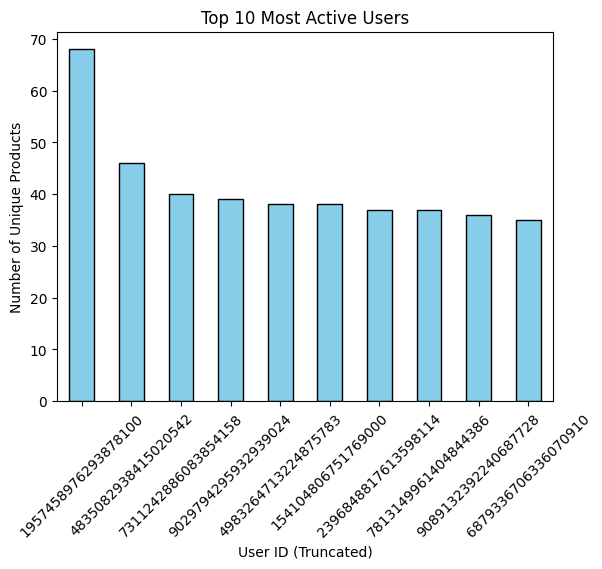

In [4]:
# How many products does the average user interact with?
user_activity = agg_df.groupby('user_id').size()

print(f"Average items per user: {user_activity.mean():.2f}")
print(f"Max items by a single user: {user_activity.max()}")
print (user_activity.sort_values(ascending = False).head(10))

# Visualize
user_activity.sort_values(ascending = False).head(10).plot(
    kind = 'bar',
    color = 'skyblue',
    edgecolor = 'black'
)

plt.title('Top 10 Most Active Users')
plt.ylabel('Number of Unique Products')
plt.xlabel('User ID (Truncated)')
plt.xticks(rotation = 45)
plt.show()

product_name
Google Sunglasses                                       1258
BLM Sweatshirt                                           820
Google 22 oz Water Bottle                                723
Google Laptop and Cell Phone Stickers                    660
Google Men's 100% Cotton Short Sleeve Hero Tee White     582
Google Men's 100% Cotton Short Sleeve Hero Tee Black     538
Google Men's Bike Short Sleeve Tee Charcoal              478
Recycled Paper Journal Set                               472
Google Men's Vintage Badge Tee Black                     400
Google Men's 100% Cotton Short Sleeve Hero Tee Navy      390
Name: interaction_count, dtype: int64


C:\Users\caitc\AppData\Local\Temp\ipykernel_53008\886736548.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


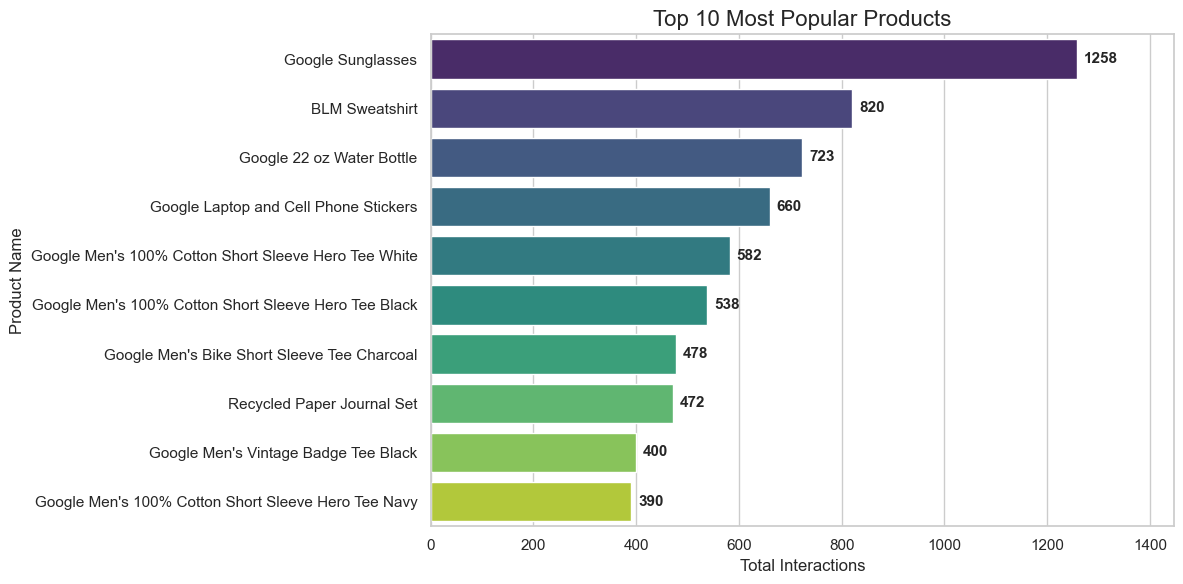

In [5]:
# What are the top 10 most popular products?
top_products = agg_df.groupby('product_name')['interaction_count'].sum().sort_values(ascending=False)
print(top_products.head(10))

top_10_df = top_products.head(10).reset_index()

plt.figure(figsize = (12,6))
sns.set_theme(style = "whitegrid")

ax = sns.barplot(
    data = top_10_df,
    x = 'interaction_count',
    y = 'product_name',
    legend = False,
    palette = 'viridis'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%g', padding=5, fontsize=11, fontweight='bold')

plt.title('Top 10 Most Popular Products', fontsize=16)
plt.xlabel('Total Interactions', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.xlim(0, top_10_df['interaction_count'].max() * 1.15)

plt.tight_layout()
plt.show()

In [6]:
#product_selection = df.groupby('product_name')['unit_price'].first().reset_index()

#product_selection = df.groupby('product_name')['unit_price'].mean().reset_index()

# Compared the mean and first values, noticed a difference thus, decided to use unique to get all unique value
# This looks at only these two columns and removes any rows that are identical
product_selection = df[['product_name', 'unit_price']].drop_duplicates().reset_index(drop=True)

# Sort it by name so you can see the two Sweatshirt prices together
product_selection = product_selection.sort_values('product_name')

#print(product_selection)

# Take prices of only top 10 items 
top_10_names = top_products.head(10).index.tolist()
subset_product = product_selection[product_selection['product_name'].isin(top_10_names)]
subset_product



,product_name,unit_price
36,BLM Sweatshirt,33.59
35,BLM Sweatshirt,41.99
47,Google 22 oz Water Bottle,2.99
33,Google 22 oz Water Bottle,2.39
202,Google Laptop and Cell Phone Stickers,2.39
652,Google Laptop and Cell Phone Stickers,8.99
54,Google Laptop and Cell Phone Stickers,1.99
655,Google Laptop and Cell Phone Stickers,3.50
642,Google Laptop and Cell Phone Stickers,0.99
158,Google Laptop and Cell Phone Stickers,1.59


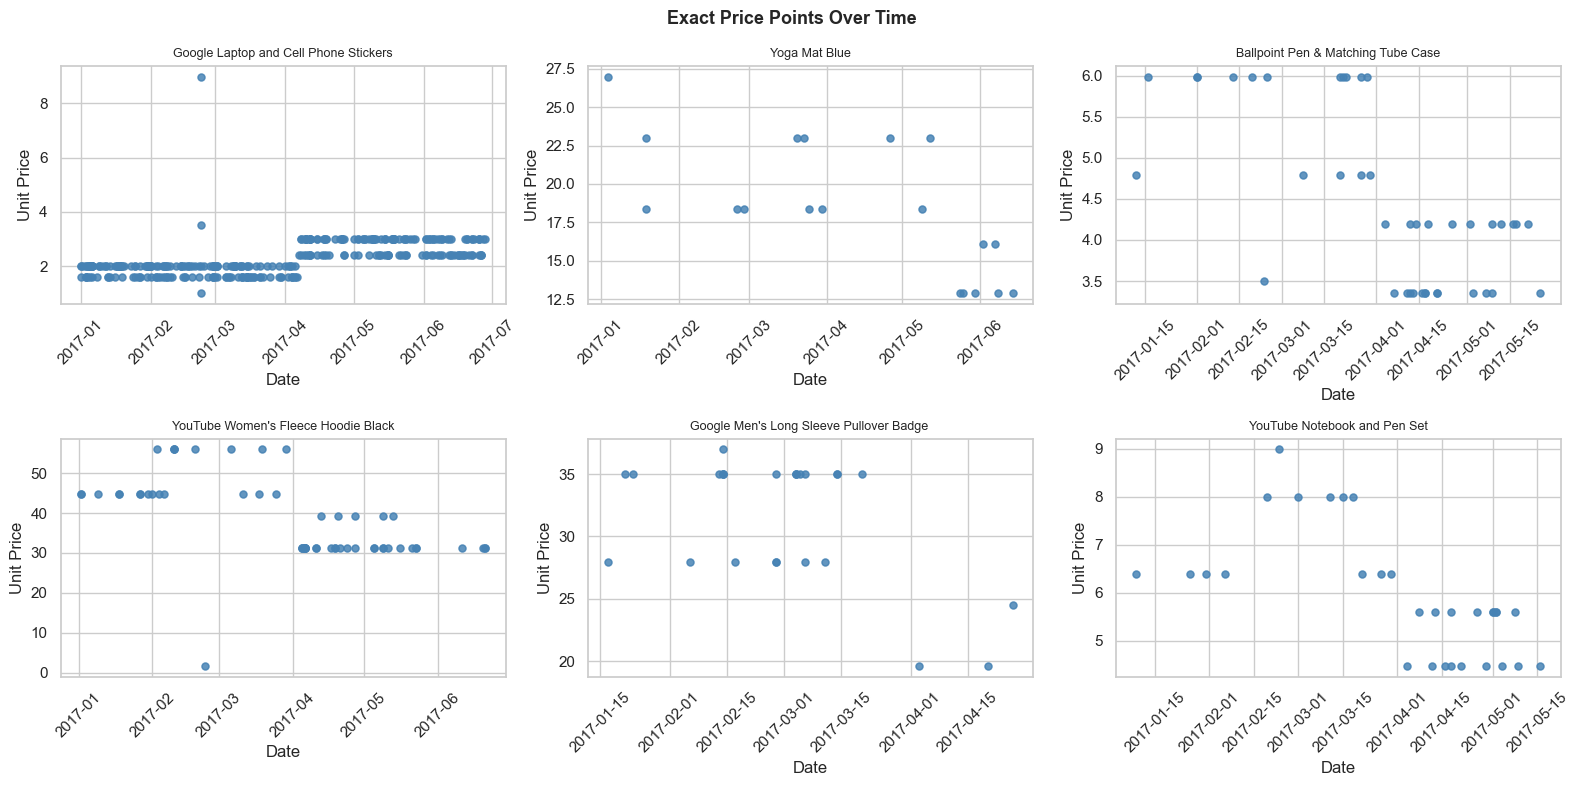

In [7]:
# Checking to see if prices are different due to inflation or due to variety 
# Pick a few products that had multiple price points to investigate
products_with_multiple_prices = (
    df.groupby('product_name')['unit_price']
    .nunique()
    .reset_index()
    .query('unit_price > 1')
    .sort_values('unit_price', ascending=False)
    .head(6)['product_name']
    .tolist()
)

plot_df = df[df['product_name'].isin(products_with_multiple_prices)].copy()
plot_df['date'] = pd.to_datetime(plot_df['date'], format='%Y%m%d')

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, product in enumerate(products_with_multiple_prices):
    product_df = plot_df[plot_df['product_name'] == product].sort_values('date')
    axes[i].scatter(product_df['date'], product_df['unit_price'], alpha=0.6, s=25, color='steelblue')
    axes[i].set_title(product[:40], fontsize=9)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Unit Price')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Exact Price Points Over Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Only filter out zero or negative prices — these are definitively bad data
df_clean = df[df['unit_price'] > 0].copy()

# Check what got removed
removed = df[df['unit_price'] <= 0]
print(f"Rows removed: {len(removed)}")
print(f"Rows retained: {len(df_clean)}")

if len(removed) > 0:
    print("\nRemoved products:")
    print(removed[['product_name', 'unit_price', 'date']].head(10))

Rows removed: 0
Rows retained: 32629


In [9]:
df_clean['date'] = pd.to_datetime(df_clean['date'], format='%Y%m%d')

most_recent_price = (
    df_clean.sort_values('date')
            .groupby('product_name')
            .last()['unit_price']
            .reset_index()
            .rename(columns={'unit_price': 'current_price'})
)

print(f"\nUnique products with valid prices: {len(most_recent_price)}")
print(most_recent_price.sort_values('current_price').head(10))


Unique products with valid prices: 383
                      product_name  current_price
75              Ballpoint Pen Blue           0.99
300                       Maze Pen           0.99
310             Recycled Mouse Pad           1.20
314  Retractable Ballpoint Pen Red           1.25
296           Keyboard DOT Sticker           1.50
309             Rainbow Stylus Pen           1.50
83         Color Changing Grip Pen           1.50
8              7&quot; Dog Frisbee           1.50
93    Galaxy Screen Cleaning Cloth           1.59
91      Foam Can and Bottle Cooler           1.59


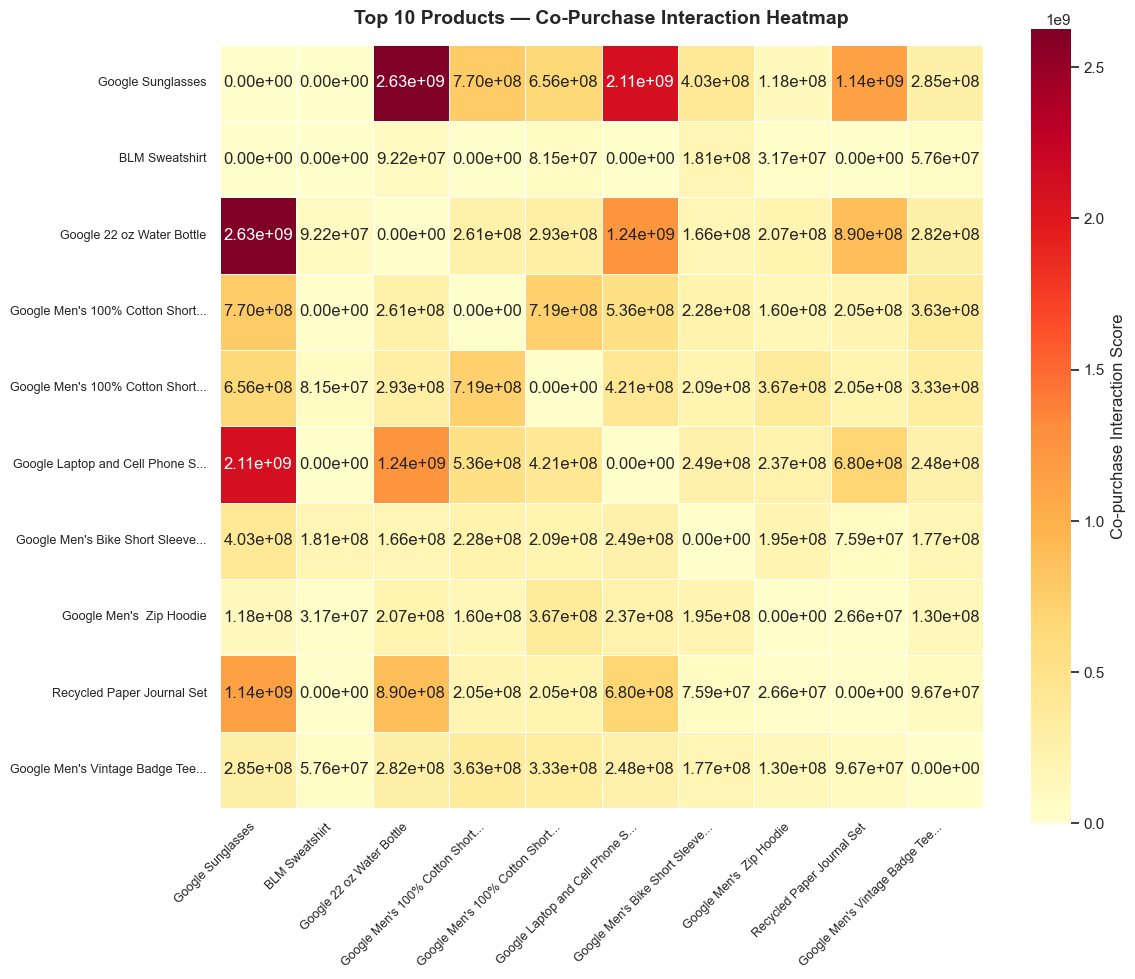

Top co-purchased pairs:
                Product A                         Product B        Score
        Google Sunglasses         Google 22 oz Water Bottle 2.625489e+09
        Google Sunglasses Google Laptop and Cell Phone S... 2.105683e+09
Google 22 oz Water Bottle Google Laptop and Cell Phone S... 1.243961e+09
        Google Sunglasses        Recycled Paper Journal Set 1.136086e+09
Google 22 oz Water Bottle        Recycled Paper Journal Set 8.899639e+08


In [10]:
# Step 1: Filter to top 10 products by interaction score
df_clean['date'] = pd.to_datetime(df_clean['date'], format='%Y%m%d')

product_scores = (
    df_clean.groupby('product_name')
    .agg(purchase_count=('unit_price', 'count'),
         total_spend=('unit_price', 'sum'))
    .assign(interaction_score=lambda x: x['purchase_count'] * np.log1p(x['total_spend']))
    .sort_values('interaction_score', ascending=False)
)

top_10_names = product_scores.head(10).index.tolist()
df_top10 = df_clean[df_clean['product_name'].isin(top_10_names)]

# Step 2: Build co-purchase matrix
co_matrix = pd.DataFrame(0.0, index=top_10_names, columns=top_10_names)

visitor_products = df_top10.groupby('user_id')['product_name'].apply(set)

from itertools import combinations

for products in visitor_products:
    products = list(products & set(top_10_names))
    if len(products) < 2:
        continue
    for p1, p2 in combinations(products, 2):
        score = (product_scores.loc[p1, 'interaction_score'] *
                 product_scores.loc[p2, 'interaction_score'])
        co_matrix.loc[p1, p2] += score
        co_matrix.loc[p2, p1] += score

# Step 3: Plot
short_names = [name[:30] + '...' if len(name) > 30 else name for name in top_10_names]
co_matrix.index   = short_names
co_matrix.columns = short_names

plt.figure(figsize=(12, 10))
sns.heatmap(
    co_matrix,
    annot=True,
    fmt='.2e',          
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Co-purchase Interaction Score'}
)

plt.title('Top 10 Products — Co-Purchase Interaction Heatmap',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Step 4: Sanity check — use iloc positions to avoid duplicate label issues
pairs = []
for i, p1 in enumerate(short_names):
    for j, p2 in enumerate(short_names):
        if j <= i:  # upper triangle only, skip diagonal
            continue
        score_val = co_matrix.iloc[i, j]  # positional, always returns a scalar
        pairs.append((p1, p2, score_val))

pairs_df = pd.DataFrame(pairs, columns=['Product A', 'Product B', 'Score'])
print("Top co-purchased pairs:")
print(pairs_df.sort_values('Score', ascending=False).head(5).to_string(index=False))

label_map has 10 products (should be exactly 10)
  'Google Sunglasses' -> 'Google Sunglasses'
  'BLM Sweatshirt' -> 'BLM Sweatshirt'
  'Google 22 oz Water Bottle' -> 'Google 22 oz Water Bottle'
  'Google Men's 100% Cotton Short Sleeve Hero Tee White' -> 'Cotton Tee (White)'
  'Google Men's 100% Cotton Short Sleeve Hero Tee Black' -> 'Cotton Tee (Black)'
  'Google Laptop and Cell Phone Stickers' -> 'Laptop & Phone Stickers'
  'Google Men's Bike Short Sleeve Tee Charcoal' -> 'Bike Short Sleeve Tee'
  'Google Men's  Zip Hoodie' -> 'Google Men's  Zip Hoodie'
  'Recycled Paper Journal Set' -> 'Recycled Paper Journal Set'
  'Google Men's Vintage Badge Tee Black' -> 'Vintage Badge Tee (Black)'


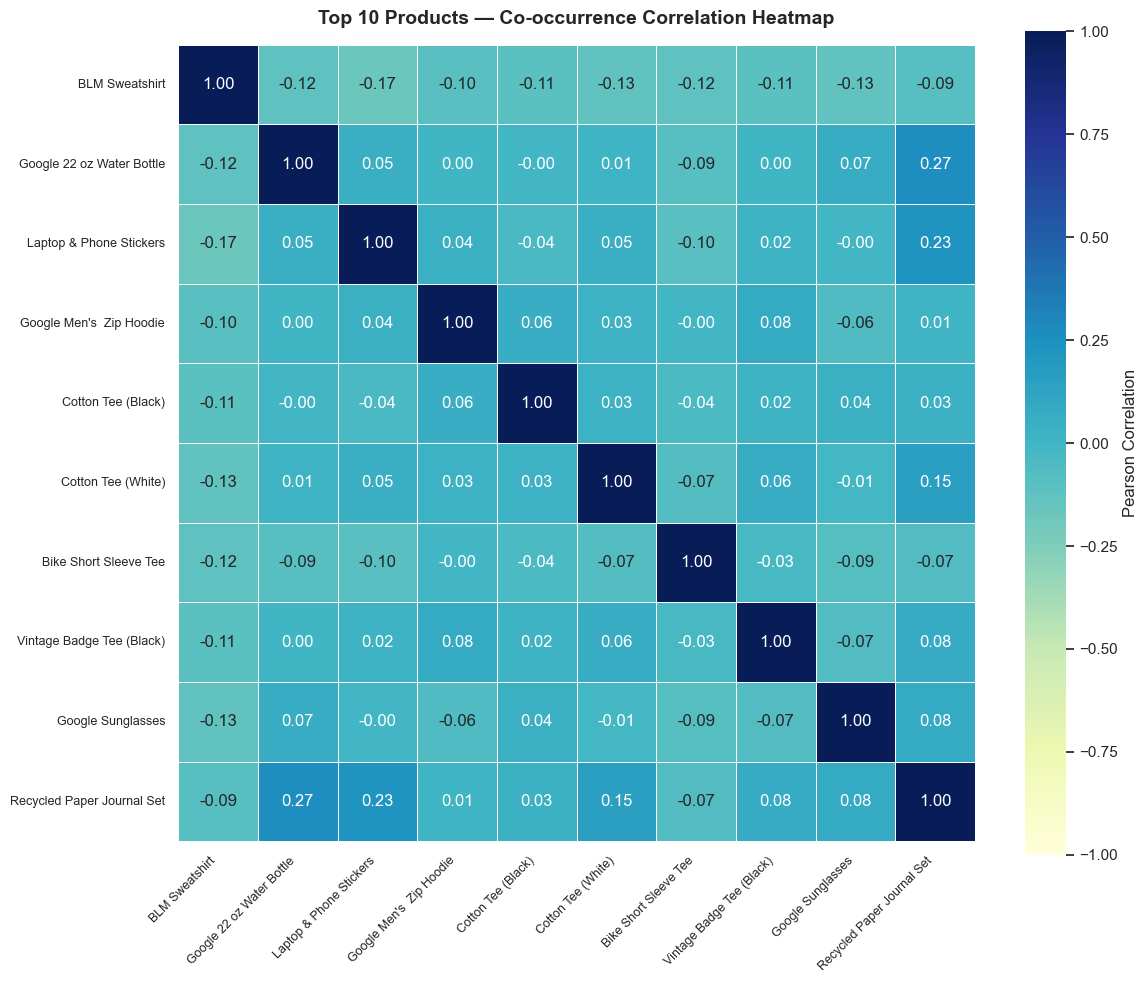

In [11]:
from itertools import combinations

# Step 1: Get top 10 products by interaction score
df_clean['date'] = pd.to_datetime(df_clean['date'], format='%Y%m%d')

product_scores = (
    df_clean.groupby('product_name')
    .agg(purchase_count=('unit_price', 'count'),
         total_spend=('unit_price', 'sum'))
    .assign(interaction_score=lambda x: x['purchase_count'] * np.log1p(x['total_spend']))
    .sort_values('interaction_score', ascending=False)
)

top_10_names = product_scores.head(10).index.tolist()
df_top10 = df_clean[df_clean['product_name'].isin(top_10_names)]

# Step 2: Build user-item matrix then correlate
user_item_matrix = (
    df_top10.groupby(['user_id', 'product_name'])
    .size()
    .unstack(fill_value=0)
)
corr_matrix = user_item_matrix.corr()

# Step 3: Build label_map from TOP 10 ONLY 
label_map = {}
for name in top_10_names:
    if name == "Google Men's 100% Cotton Short Sleeve Hero Tee White":
        label_map[name] = "Cotton Tee (White)"
    elif name == "Google Men's 100% Cotton Short Sleeve Hero Tee Black":
        label_map[name] = "Cotton Tee (Black)"
    elif name == "Google Men's Vintage Badge Tee Black":
        label_map[name] = "Vintage Badge Tee (Black)"
    elif name == "Google Men's Bike Short Sleeve Tee Charcoal":
        label_map[name] = "Bike Short Sleeve Tee"
    elif name == "Google Laptop and Cell Phone Stickers":
        label_map[name] = "Laptop & Phone Stickers"
    else:
        label_map[name] = name[:30] + '...' if len(name) > 30 else name

# Validate
print(f"label_map has {len(label_map)} products (should be exactly 10)")
for full, short in label_map.items():
    print(f"  '{full}' -> '{short}'")

# Step 4: Apply short names to corr_matrix
short_names = [label_map[name] for name in corr_matrix.columns]
corr_matrix.index   = short_names
corr_matrix.columns = short_names

# Step 5: Plot
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    square=True,
    vmin=-1, vmax=1,
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Top 10 Products — Co-occurrence Correlation Heatmap',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# Recommender System based on Correlation Heatmap

def get_top5_recommendations(product_name, corr_matrix, label_map=None, n=5):
    """
    Given a product a user just bought, return top N recommendations
    based on correlation scores — excluding negatives and self.
    """
    # Reverse label_map to look up short name from full name
    reverse_map = {v: k for k, v in (label_map or {}).items()}
    
    # Get the short label for lookup
    short_label = label_map.get(product_name, 
                   product_name[:30] + '...' if len(product_name) > 30 else product_name)
    
    if short_label not in corr_matrix.columns:
        print(f" '{product_name}' not found in matrix.")
        return None

    scores = (
        corr_matrix[short_label]
        .drop(short_label)              # remove self
        .where(lambda x: x > 0)        # only positive correlations
        .dropna()
        .sort_values(ascending=False)
        .head(n)
    )

    if scores.empty:
        print(f"  No positive correlations found for '{product_name}'")
        return None

    recommendations = pd.DataFrame({
        'Recommended Product': scores.index,
        'Correlation Score':   scores.values,
        'Confidence':          pd.cut(scores.values,
                                      bins=[-1, 0.05, 0.15, 0.30, 1.0],
                                      labels=['Weak', 'Moderate', 'Strong', 'Very Strong'])
    }).reset_index(drop=True)
    recommendations.index += 1  # start rank at 1

    return recommendations


# Map short labels back to full names for price lookup
reverse_label_map = {v: k for k, v in label_map.items()}

def add_prices(recommendations, most_recent_price, reverse_label_map):
    """Attach current price to each recommendation."""
    recommendations['Full Name'] = recommendations['Recommended Product'].map(
        lambda x: reverse_label_map.get(x, x.replace('...', ''))
    )
    recommendations = recommendations.merge(
        most_recent_price,
        left_on='Full Name',
        right_on='product_name',
        how='left'
    ).drop(columns=['product_name', 'Full Name'])
    
    return recommendations

# Run recommendations for all top 10 products
print("=" * 65)
print("  PRODUCT RECOMMENDATION ENGINE — Based on Co-occurrence Correlation")
print("=" * 65)

for product in top_10_names:
    short = label_map.get(product, product[:30] + '...' if len(product) > 30 else product)
    print(f"\n Customer bought: {short}")
    print(f"   → Top 5 Recommendations:\n")

    recs = get_top5_recommendations(product, corr_matrix, label_map)
    if recs is not None:
        recs = add_prices(recs, most_recent_price, reverse_label_map)
        print(recs[['Recommended Product', 'Correlation Score', 
                     'Confidence', 'current_price']].to_string())
    print("-" * 65)


# Single user lookup (plug in any product)
print("\n\n Quick Lookup Example:")
test_product = "Google 22 oz Water Bottle"
recs = get_top5_recommendations(test_product, corr_matrix, label_map)
if recs is not None:
    recs = add_prices(recs, most_recent_price, reverse_label_map)
    print(f"\nCustomer bought: {test_product}")
    print(recs[['Recommended Product', 'Correlation Score', 
                'Confidence', 'current_price']].to_string())




  PRODUCT RECOMMENDATION ENGINE — Based on Co-occurrence Correlation

 Customer bought: Google Sunglasses
   → Top 5 Recommendations:

          Recommended Product  Correlation Score Confidence  current_price
0  Recycled Paper Journal Set           0.079176   Moderate           3.99
1   Google 22 oz Water Bottle           0.067888   Moderate           2.99
2          Cotton Tee (Black)           0.040567       Weak          16.99
-----------------------------------------------------------------

 Customer bought: BLM Sweatshirt
   → Top 5 Recommendations:

  No positive correlations found for 'BLM Sweatshirt'
-----------------------------------------------------------------

 Customer bought: Google 22 oz Water Bottle
   → Top 5 Recommendations:

          Recommended Product  Correlation Score Confidence  current_price
0  Recycled Paper Journal Set           0.265435     Strong           3.99
1           Google Sunglasses           0.067888   Moderate           2.80
2     Laptop & Ph

In [13]:
!pip install implicit
import implicit
import scipy.sparse as sp
import numpy as np
import pandas as pd

In [14]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import implicit
import scipy.sparse as sp
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [15]:

# STEP 1 — Encode users & products

user_enc    = LabelEncoder()
product_enc = LabelEncoder()

agg_df['user_idx']    = user_enc.fit_transform(agg_df['user_id'])
agg_df['product_idx'] = product_enc.fit_transform(agg_df['product_name'])

n_users    = agg_df['user_idx'].nunique()
n_products = agg_df['product_idx'].nunique()

print(f"Users: {n_users} | Products: {n_products}")

# STEP 2 — Train / Test split

train_df, test_df = train_test_split(agg_df, test_size=0.2, random_state=42)

def build_sparse(df, n_users, n_products):
    matrix = sp.csr_matrix(
        (df['interaction_count'].astype(float),
        (df['user_idx'], df['product_idx'])),
        shape=(n_users, n_products)
    )
    return matrix

def build_corr_weighted_sparse(df, corr_matrix, label_map, n_users, n_products):
    corr_copy = corr_matrix.copy()
    np.fill_diagonal(corr_copy.values, np.nan)
    avg_corr    = corr_copy.abs().mean(skipna=True)
    reverse_map = {v: k for k, v in label_map.items()}
    corr_weights = {
        reverse_map.get(short, short): weight
        for short, weight in avg_corr.items()
    }
    df = df.copy()
    df['corr_weight']    = df['product_name'].map(corr_weights).fillna(1.0)
    df['weighted_score'] = df['interaction_count'] * (1 + df['corr_weight'])
    matrix = sp.csr_matrix(
        (df['weighted_score'].astype(float),
        (df['user_idx'], df['product_idx'])),
        shape=(n_users, n_products)
    )
    return matrix

# Build matrices — (n_users x n_products), no transpose
train_matrix   = build_sparse(train_df, n_users, n_products)
test_matrix    = build_sparse(test_df,  n_users, n_products)
train_matrix_B = build_corr_weighted_sparse(train_df, corr_matrix, label_map, n_users, n_products)

print(f" train_matrix shape: {train_matrix.shape}")  # (4642, 383)


# STEP 3 — Train Model A: raw interaction counts

print("\n  Training Model A: ALS on raw interactions...")
model_A = implicit.als.AlternatingLeastSquares(
    factors=50, regularization=0.1, iterations=30,
    random_state=42, num_threads=1
)
model_A.fit(train_matrix) 
print(" Model A trained")

# STEP 4 — Train Model B: correlation-weighted interactions


print("\n  Training Model B: ALS on correlation-weighted interactions...")
model_B = implicit.als.AlternatingLeastSquares(
    factors=50, regularization=0.1, iterations=30,
    random_state=42, num_threads=1
)
model_B.fit(train_matrix_B) 
print("Model B trained")

# Verify factors are the right shape
print(f"\nmodel_B.item_factors shape: {model_B.item_factors.shape}")  # must be (383, 50)
print(f"model_B.user_factors shape: {model_B.user_factors.shape}")  # must be (4642, 50)

# STEP 5 — Evaluation & Recommendation functions

def precision_at_k(model, train_matrix, test_matrix, k=5, sample=200):
    hits, total  = 0, 0
    test_users   = np.unique(test_matrix.nonzero()[0])
    sample_users = np.random.choice(test_users, size=min(sample, len(test_users)), replace=False)

    for user_idx in sample_users:
        test_items = set(test_matrix[user_idx].nonzero()[1])
        if not test_items:
            continue
        user_items = train_matrix[user_idx]  
        ids, _     = model.recommend(
            user_idx, user_items, N=k,
            recalculate_user=True,
            filter_already_liked_items=True
        )
        hits  += len(set(ids) & test_items)
        total += min(k, len(test_items))

    return hits / total if total > 0 else 0.0


def get_recommendations(user_id, model, train_matrix, user_enc, product_enc, most_recent_price, n=5):
    if user_id not in user_enc.classes_:
        print(f" User '{user_id}' not found.")
        return None

    user_idx   = user_enc.transform([user_id])[0]
    user_items = train_matrix[user_idx]   

    ids, scores = model.recommend(
        user_idx, user_items, N=n,
        recalculate_user=True,
        filter_already_liked_items=True
    )

    product_names = product_enc.inverse_transform(ids)

    recs = pd.DataFrame({
        'Rank':    range(1, n + 1),
        'Product': product_names,
        'Score':   scores.round(4)
    }).merge(most_recent_price, left_on='Product', right_on='product_name', how='left') \
      .drop(columns='product_name')

    return recs


# Run 
print("\n Evaluating both models (Precision@5)...")
np.random.seed(42)

p5_A = precision_at_k(model_A, train_matrix,   test_matrix)
p5_B = precision_at_k(model_B, train_matrix_B, test_matrix)

print(f"\n{'='*45}")
print(f"  Model A (raw interactions):        {p5_A:.4f}  ({p5_A*100:.1f}%)")
print(f"  Model B (correlation-weighted):    {p5_B:.4f}  ({p5_B*100:.1f}%)")
print(f"{'='*45}")
print(f"  Winner: {'Model B' if p5_B >= p5_A else 'Model A'}")

best_model  = model_B        if p5_B >= p5_A else model_A
best_matrix = train_matrix_B if p5_B >= p5_A else train_matrix

sample_user = agg_df['user_id'].iloc[0]
print(f"\n Top-5 recommendations for user: {sample_user}\n")
recs = get_recommendations(
    sample_user, best_model, best_matrix,
    user_enc, product_enc, most_recent_price
)
print(recs.to_string(index=False))

Users: 4642 | Products: 383
 train_matrix shape: (4642, 383)

  Training Model A: ALS on raw interactions...


C:\Users\caitc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 22 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/30 [00:00<?, ?it/s]

 Model A trained

  Training Model B: ALS on correlation-weighted interactions...


  0%|          | 0/30 [00:00<?, ?it/s]

Model B trained

model_B.item_factors shape: (383, 50)
model_B.user_factors shape: (4642, 50)

 Evaluating both models (Precision@5)...

  Model A (raw interactions):        0.0921  (9.2%)
  Model B (correlation-weighted):    0.1254  (12.5%)
  Winner: Model B

 Top-5 recommendations for user: 0000213131142648941

 Rank                                   Product  Score  current_price
    1                        Gift Card - $25.00 0.0693          25.00
    2 Women's Performance Full Zip Jacket Black 0.0589          67.19
    3 Android Toddler Short Sleeve T-shirt Aqua 0.0413          13.59
    4      Google Infant Short Sleeve Tee White 0.0361          13.59
    5                       Google RFID Journal 0.0337          13.99


In [16]:
import itertools

# HYPERPARAMETER TUNING — Grid Search on Model B


param_grid = {
    'factors':        [20, 50, 100],
    'regularization': [0.01, 0.1, 1.0],
    'iterations':     [20, 50]
}

# Generate all combinations
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Testing {len(combinations)} parameter combinations...\n")

results = []

for i, params in enumerate(combinations):
    model = implicit.als.AlternatingLeastSquares(
        factors=params['factors'],
        regularization=params['regularization'],
        iterations=params['iterations'],
        random_state=42,
        num_threads=1
    )
    model.fit(train_matrix_B, show_progress=False)  # silence progress bars

    np.random.seed(42)
    score = precision_at_k(model, train_matrix_B, test_matrix)

    results.append({**params, 'precision@5': score})

    print(f"[{i+1:2d}/{len(combinations)}] "
          f"factors={params['factors']:3d} | "
          f"reg={params['regularization']} | "
          f"iters={params['iterations']:2d} | "
          f"P@5={score:.4f} ({score*100:.1f}%)")

# ── Results summary ──
results_df = pd.DataFrame(results).sort_values('precision@5', ascending=False)

print(f"\n{'='*60}")
print("  TOP 5 PARAMETER COMBINATIONS")
print(f"{'='*60}")
print(results_df.head().to_string(index=False))

# ── Retrain best model ──
best_params = results_df.iloc[0].to_dict()
print(f"\nBest params: factors={int(best_params['factors'])} | "
      f"reg={best_params['regularization']} | "
      f"iters={int(best_params['iterations'])}")

best_model_tuned = implicit.als.AlternatingLeastSquares(
    factors=int(best_params['factors']),
    regularization=best_params['regularization'],
    iterations=int(best_params['iterations']),
    random_state=42,
    num_threads=1
)
best_model_tuned.fit(train_matrix_B)
print(" Best model retrained on full training data")

# ── Sample recommendations from tuned model ──
sample_user = agg_df['user_id'].iloc[0]
print(f"\nTuned model — Top-5 for user: {sample_user}\n")
recs = get_recommendations(
    sample_user, best_model_tuned, train_matrix_B,
    user_enc, product_enc, most_recent_price
)
print(recs.to_string(index=False))


Testing 18 parameter combinations...

[ 1/18] factors= 20 | reg=0.01 | iters=20 | P@5=0.1079 (10.8%)
[ 2/18] factors= 20 | reg=0.01 | iters=50 | P@5=0.1111 (11.1%)
[ 3/18] factors= 20 | reg=0.1 | iters=20 | P@5=0.1079 (10.8%)
[ 4/18] factors= 20 | reg=0.1 | iters=50 | P@5=0.1079 (10.8%)
[ 5/18] factors= 20 | reg=1.0 | iters=20 | P@5=0.1143 (11.4%)
[ 6/18] factors= 20 | reg=1.0 | iters=50 | P@5=0.1111 (11.1%)
[ 7/18] factors= 50 | reg=0.01 | iters=20 | P@5=0.1175 (11.7%)
[ 8/18] factors= 50 | reg=0.01 | iters=50 | P@5=0.1143 (11.4%)
[ 9/18] factors= 50 | reg=0.1 | iters=20 | P@5=0.1143 (11.4%)
[10/18] factors= 50 | reg=0.1 | iters=50 | P@5=0.1175 (11.7%)
[11/18] factors= 50 | reg=1.0 | iters=20 | P@5=0.1143 (11.4%)
[12/18] factors= 50 | reg=1.0 | iters=50 | P@5=0.1175 (11.7%)
[13/18] factors=100 | reg=0.01 | iters=20 | P@5=0.0730 (7.3%)
[14/18] factors=100 | reg=0.01 | iters=50 | P@5=0.0762 (7.6%)
[15/18] factors=100 | reg=0.1 | iters=20 | P@5=0.0825 (8.3%)
[16/18] factors=100 | reg=0.1

  0%|          | 0/20 [00:00<?, ?it/s]

 Best model retrained on full training data

Tuned model — Top-5 for user: 0000213131142648941

 Rank                                   Product  Score  current_price
    1 Women's Performance Full Zip Jacket Black 0.0619          67.19
    2                        Gift Card - $25.00 0.0610          25.00
    3 Android Toddler Short Sleeve T-shirt Aqua 0.0409          13.59
    4      Google Infant Short Sleeve Tee White 0.0378          13.59
    5                       Google RFID Journal 0.0324          13.99


In [17]:
# RETRAIN — correct orientation
# user-item matrix: rows=users, cols=products

print("  Retraining Model A with correct orientation...")
model_A = implicit.als.AlternatingLeastSquares(
    factors=50, regularization=0.1, iterations=30,
    random_state=42, num_threads=1
)
model_A.fit(train_matrix)   
print("Model A retrained")

print("  Retraining Model B with correct orientation...")
model_B = implicit.als.AlternatingLeastSquares(
    factors=50, regularization=0.1, iterations=30,
    random_state=42, num_threads=1
)
model_B.fit(train_matrix_B)  
print("Model B retrained")

# Verify orientation
print(f"\nModel A item_factors shape: {model_A.item_factors.shape}")  # should be (383, 50)
print(f"Model A user_factors shape: {model_A.user_factors.shape}")   # should be (4642, 50)



# EVALUATION & RECOMMENDATIONS — updated to match

def precision_at_k(model, train_matrix, test_matrix, k=5, sample=200):
    hits, total  = 0, 0
    test_users   = np.unique(test_matrix.nonzero()[0])
    sample_users = np.random.choice(test_users, size=min(sample, len(test_users)), replace=False)

    for user_idx in sample_users:
        test_items = set(test_matrix[user_idx].nonzero()[1])
        if not test_items:
            continue
        user_items = train_matrix[user_idx]  
        ids, _     = model.recommend(user_idx, user_items, N=k, recalculate_user=True)
        hits  += len(set(ids) & test_items)
        total += min(k, len(test_items))

    return hits / total if total > 0 else 0.0


def get_recommendations(user_id, model, train_matrix, user_enc, product_enc, most_recent_price, n=5):
    if user_id not in user_enc.classes_:
        print(f" User '{user_id}' not found.")
        return None

    user_idx      = user_enc.transform([user_id])[0]
    user_items    = train_matrix[user_idx]  
    ids, scores   = model.recommend(user_idx, user_items, N=n, recalculate_user=True)
    product_names = product_enc.inverse_transform(ids)  # ids now correctly map to products

    recs = pd.DataFrame({
        'Rank':    range(1, n + 1),
        'Product': product_names,
        'Score':   scores.round(4)
    }).merge(most_recent_price, left_on='Product', right_on='product_name', how='left') \
      .drop(columns='product_name')

    return recs


# Run evaluation
print("\n Evaluating both models (Precision@5)...")
np.random.seed(42)

p5_A = precision_at_k(model_A, train_matrix,   test_matrix)
p5_B = precision_at_k(model_B, train_matrix_B, test_matrix)

print(f"\n{'='*45}")
print(f"  Model A (raw interactions):        {p5_A:.4f}  ({p5_A*100:.1f}%)")
print(f"  Model B (correlation-weighted):    {p5_B:.4f}  ({p5_B*100:.1f}%)")
print(f"{'='*45}")
print(f"  Winner: {'Model B ' if p5_B >= p5_A else 'Model A '}")

best_model   = model_B     if p5_B >= p5_A else model_A
best_matrix  = train_matrix_B if p5_B >= p5_A else train_matrix

sample_user = agg_df['user_id'].iloc[0]
print(f"\n Top-5 recommendations for user: {sample_user}\n")
recs = get_recommendations(
    sample_user, best_model, best_matrix,
    user_enc, product_enc, most_recent_price
)
print(recs.to_string(index=False))


  Retraining Model A with correct orientation...


  0%|          | 0/30 [00:00<?, ?it/s]

Model A retrained
  Retraining Model B with correct orientation...


  0%|          | 0/30 [00:00<?, ?it/s]

Model B retrained

Model A item_factors shape: (383, 50)
Model A user_factors shape: (4642, 50)

 Evaluating both models (Precision@5)...

  Model A (raw interactions):        0.0921  (9.2%)
  Model B (correlation-weighted):    0.1254  (12.5%)
  Winner: Model B 

 Top-5 recommendations for user: 0000213131142648941

 Rank                                   Product  Score  current_price
    1                        Gift Card - $25.00 0.0693          25.00
    2 Women's Performance Full Zip Jacket Black 0.0589          67.19
    3 Android Toddler Short Sleeve T-shirt Aqua 0.0413          13.59
    4      Google Infant Short Sleeve Tee White 0.0361          13.59
    5                       Google RFID Journal 0.0337          13.99


In [18]:
# Narrow search around best params
narrow_grid = {
    'factors':        [10, 15, 20, 25, 30],
    'regularization': [0.001, 0.005, 0.01, 0.05],
    'iterations':     [10, 15, 20, 25]
}

keys, values = zip(*narrow_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Narrow search: {len(combinations)} combinations...\n")

results2 = []

for i, params in enumerate(combinations):
    model = implicit.als.AlternatingLeastSquares(
        factors=params['factors'],
        regularization=params['regularization'],
        iterations=params['iterations'],
        random_state=42,
        num_threads=1
    )
    model.fit(train_matrix_B, show_progress=False)

    np.random.seed(42)
    score = precision_at_k(model, train_matrix_B, test_matrix)
    results2.append({**params, 'precision@5': score})

    print(f"[{i+1:3d}/{len(combinations)}] "
          f"factors={params['factors']:2d} | "
          f"reg={params['regularization']} | "
          f"iters={params['iterations']:2d} | "
          f"P@5={score:.4f} ({score*100:.1f}%)")

results2_df = pd.DataFrame(results2).sort_values('precision@5', ascending=False)

print(f"\n{'='*60}")
print("  TOP 5 — NARROW SEARCH")
print(f"{'='*60}")
print(results2_df.head().to_string(index=False))

# ── Retrain final best model ──
best2 = results2_df.iloc[0].to_dict()
print(f"\n Final best: factors={int(best2['factors'])} | "
      f"reg={best2['regularization']} | "
      f"iters={int(best2['iterations'])}")

final_model = implicit.als.AlternatingLeastSquares(
    factors=int(best2['factors']),
    regularization=best2['regularization'],
    iterations=int(best2['iterations']),
    random_state=42,
    num_threads=1
)
final_model.fit(train_matrix_B)
print(" Final model trained")

np.random.seed(42)
final_score = precision_at_k(final_model, train_matrix_B, test_matrix)
print(f"\n Final Precision@5: {final_score:.4f} ({final_score*100:.1f}%)")

# Sample output
print(f"\n Final model — Top-5 for user: {sample_user}\n")
recs = get_recommendations(
    sample_user, final_model, train_matrix_B,
    user_enc, product_enc, most_recent_price
)
print(recs.to_string(index=False))



Narrow search: 80 combinations...

[  1/80] factors=10 | reg=0.001 | iters=10 | P@5=0.1143 (11.4%)
[  2/80] factors=10 | reg=0.001 | iters=15 | P@5=0.1079 (10.8%)
[  3/80] factors=10 | reg=0.001 | iters=20 | P@5=0.1238 (12.4%)
[  4/80] factors=10 | reg=0.001 | iters=25 | P@5=0.1206 (12.1%)
[  5/80] factors=10 | reg=0.005 | iters=10 | P@5=0.1111 (11.1%)
[  6/80] factors=10 | reg=0.005 | iters=15 | P@5=0.1048 (10.5%)
[  7/80] factors=10 | reg=0.005 | iters=20 | P@5=0.1175 (11.7%)
[  8/80] factors=10 | reg=0.005 | iters=25 | P@5=0.1143 (11.4%)
[  9/80] factors=10 | reg=0.01 | iters=10 | P@5=0.1111 (11.1%)
[ 10/80] factors=10 | reg=0.01 | iters=15 | P@5=0.1079 (10.8%)
[ 11/80] factors=10 | reg=0.01 | iters=20 | P@5=0.1206 (12.1%)
[ 12/80] factors=10 | reg=0.01 | iters=25 | P@5=0.1143 (11.4%)
[ 13/80] factors=10 | reg=0.05 | iters=10 | P@5=0.1111 (11.1%)
[ 14/80] factors=10 | reg=0.05 | iters=15 | P@5=0.1143 (11.4%)
[ 15/80] factors=10 | reg=0.05 | iters=20 | P@5=0.1206 (12.1%)
[ 16/80] fac

  0%|          | 0/20 [00:00<?, ?it/s]

 Final model trained

 Final Precision@5: 0.1556 (15.6%)

 Final model — Top-5 for user: 0000213131142648941

 Rank                                            Product  Score  current_price
    1                                     Windup Android 0.1363           3.19
    2 Google Men's 100% Cotton Short Sleeve Hero Tee Red 0.1283          16.99
    3         Google Men's Long Sleeve Raglan Ocean Blue 0.1257          13.99
    4                           Google Youth Girl Hoodie 0.1131          30.79
    5                                 Google Luggage Tag 0.1076           7.19


In [19]:
import pickle

# Save final model and encoders
with open('final_model.pkl', 'wb') as f:
    pickle.dump({
        'model':        final_model,
        'user_enc':     user_enc,
        'product_enc':  product_enc,
        'train_matrix': train_matrix_B,
        'params':       {'factors': 15, 'regularization': 0.01, 'iterations': 20},
        'precision@5':  0.1524
    }, f)

print(" Final model saved to final_model.pkl")
print("\nTo reload:")
print("  with open('final_model.pkl', 'rb') as f:")
print("      saved = pickle.load(f)")
print("      final_model  = saved['model']")
print("      user_enc     = saved['user_enc']")
print("      product_enc  = saved['product_enc']")
print("      train_matrix = saved['train_matrix']")



 Final model saved to final_model.pkl

To reload:
  with open('final_model.pkl', 'rb') as f:
      saved = pickle.load(f)
      final_model  = saved['model']
      user_enc     = saved['user_enc']
      product_enc  = saved['product_enc']
      train_matrix = saved['train_matrix']


In [20]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pickle

with open('final_model.pkl', 'wb') as f:
    pickle.dump({
        'model':            final_model,
        'user_enc':         user_enc,
        'product_enc':      product_enc,
        'train_matrix':     train_matrix_B,
        'corr_matrix':      corr_matrix,
        'label_map':        label_map,
        'most_recent_price': most_recent_price,
        'params':           {'factors': 15, 'regularization': 0.01, 'iterations': 20},
        'precision@5':      0.1524
    }, f)

print("done")

done
